In [1]:
import pandas as pd
import numpy as np
import joblib
import random

In [2]:
model = joblib.load(
    '../models/xgb_wc_predictor.pkl'
)

In [3]:
elo = pd.read_csv(
    '../data/raw/elo_ratings.csv'
)

elo['snapshot_date'] = pd.to_datetime(
    elo['snapshot_date']
)

latest_elo = (
    elo.sort_values('snapshot_date')
       .groupby('country')
       .tail(1)
)

In [4]:
elo_dict = dict(
    zip(
        latest_elo['country'],
        latest_elo['rating']
    )
)

In [5]:
groups = {

    'Group A': [
        'Mexico',
        'France',
        'Japan',
        'Ghana'
    ],

    'Group B': [
        'Brazil',
        'USA',
        'Iran',
        'Switzerland'
    ],

    'Group C': [
        'Argentina',
        'England',
        'South Korea',
        'Morocco'
    ],

    'Group D': [
        'Spain',
        'Germany',
        'Saudi Arabia',
        'Canada'
    ]
}

In [6]:
from itertools import combinations

In [7]:
group_matches = []

for group_name, teams in groups.items():

    matches = list(
        combinations(teams, 2)
    )

    for home, away in matches:

        group_matches.append({
            'group': group_name,
            'home_team': home,
            'away_team': away
        })

In [8]:
fixtures = pd.DataFrame(group_matches)

fixtures.head()

,group,home_team,away_team
0,Group A,Mexico,France
1,Group A,Mexico,Japan
2,Group A,Mexico,Ghana
3,Group A,France,Japan
4,Group A,France,Ghana


In [9]:
def create_match_features(
    home_team,
    away_team
):

    home_elo = elo_dict.get(home_team, 1500)
    away_elo = elo_dict.get(away_team, 1500)

    elo_diff = home_elo - away_elo

    features = pd.DataFrame({

        'home_elo': [home_elo],
        'away_elo': [away_elo],
        'elo_diff': [elo_diff],

        'home_rank': [50],
        'away_rank': [50],
        'rank_diff': [0],

        'neutral': [1],
        'is_competitive': [1],

        'home_form': [1.5],
        'away_form': [1.5],
        'form_diff': [0],

        'home_attack_strength': [1.5],
        'away_attack_strength': [1.5],

        'home_defense_strength': [1.0],
        'away_defense_strength': [1.0]
    })

    return features

In [10]:
def predict_match(
    home_team,
    away_team
):

    features = create_match_features(
        home_team,
        away_team
    )

    probs = model.predict_proba(features)[0]

    return probs

In [11]:
def simulate_match(
    home_team,
    away_team
):

    probs = predict_match(
        home_team,
        away_team
    )

    outcome = np.random.choice(
        [0,1,2],
        p=probs
    )

    return outcome

In [12]:
standings = {}

for group_name, teams in groups.items():

    standings[group_name] = pd.DataFrame({

        'team': teams,
        'points': 0,
        'gf': 0,
        'ga': 0,
        'gd': 0
    })

In [13]:
for _, row in fixtures.iterrows():

    group = row['group']

    home = row['home_team']
    away = row['away_team']

    result = simulate_match(
        home,
        away
    )

    if result == 2:

        standings[group].loc[
            standings[group]['team'] == home,
            'points'
        ] += 3

    elif result == 0:

        standings[group].loc[
            standings[group]['team'] == away,
            'points'
        ] += 3

    else:

        standings[group].loc[
            standings[group]['team'] == home,
            'points'
        ] += 1

        standings[group].loc[
            standings[group]['team'] == away,
            'points'
        ] += 1

In [14]:
for group_name in standings:

    print("\n", group_name)

    print(
        standings[group_name]
        .sort_values(
            by='points',
            ascending=False
        )
    )


 Group A
     team  points  gf  ga  gd
3   Ghana       5   0   0   0
0  Mexico       4   0   0   0
1  France       4   0   0   0
2   Japan       3   0   0   0

 Group B
          team  points  gf  ga  gd
2         Iran       7   0   0   0
0       Brazil       4   0   0   0
3  Switzerland       4   0   0   0
1          USA       1   0   0   0

 Group C
          team  points  gf  ga  gd
3      Morocco       9   0   0   0
0    Argentina       3   0   0   0
1      England       3   0   0   0
2  South Korea       3   0   0   0

 Group D
           team  points  gf  ga  gd
2  Saudi Arabia       5   0   0   0
3        Canada       5   0   0   0
1       Germany       3   0   0   0
0         Spain       2   0   0   0


In [15]:
qualified_teams = []

In [16]:
for group_name in standings:

    table = standings[group_name].sort_values(
        by='points',
        ascending=False
    )

    winner = table.iloc[0]['team']
    runner_up = table.iloc[1]['team']

    qualified_teams.append(winner)
    qualified_teams.append(runner_up)

In [17]:
print(qualified_teams)

['Ghana', 'Mexico', 'Iran', 'Brazil', 'Morocco', 'Argentina', 'Saudi Arabia', 'Canada']


In [18]:
quarterfinals = [

    (
        qualified_teams[0],
        qualified_teams[3]
    ),

    (
        qualified_teams[2],
        qualified_teams[1]
    ),

    (
        qualified_teams[4],
        qualified_teams[7]
    ),

    (
        qualified_teams[6],
        qualified_teams[5]
    )
]

In [19]:
semifinalists = []

In [20]:
for home, away in quarterfinals:

    result = simulate_match(
        home,
        away
    )

    if result == 2:
        semifinalists.append(home)

    elif result == 0:
        semifinalists.append(away)

    else:
        winner = random.choice(
            [home, away]
        )

        semifinalists.append(winner)

In [21]:
for home, away in quarterfinals:

    result = simulate_match(
        home,
        away
    )

    if result == 2:
        semifinalists.append(home)

    elif result == 0:
        semifinalists.append(away)

    else:
        winner = random.choice(
            [home, away]
        )

        semifinalists.append(winner)

In [22]:
print("Semifinalists:")
print(semifinalists)

Semifinalists:
['Brazil', 'Mexico', 'Canada', 'Argentina', 'Brazil', 'Mexico', 'Canada', 'Argentina']


In [23]:
semifinals = [

    (
        semifinalists[0],
        semifinalists[1]
    ),

    (
        semifinalists[2],
        semifinalists[3]
    )
]

In [24]:
finalists = []

In [25]:
for home, away in semifinals:

    result = simulate_match(
        home,
        away
    )

    if result == 2:
        finalists.append(home)

    elif result == 0:
        finalists.append(away)

    else:
        winner = random.choice(
            [home, away]
        )

        finalists.append(winner)

In [27]:
print('Finalists:')
print(finalists)

Finalists:
['Mexico', 'Argentina', 'Brazil', 'Argentina']


In [28]:
home = finalists[0]
away = finalists[1]

result = simulate_match(
    home,
    away
)

In [29]:
if result == 2:

    champion = home

elif result == 0:

    champion = away

else:

    champion = random.choice(
        [home, away]
    )

In [30]:
print("🏆 WORLD CUP CHAMPION:")
print(champion)

🏆 WORLD CUP CHAMPION:
Argentina


In [31]:
#Full Tournament Simulation

In [32]:
def run_tournament():

    standings = {}

    for group_name, teams in groups.items():

        standings[group_name] = pd.DataFrame({

            'team': teams,
            'points': 0
        })

    for _, row in fixtures.iterrows():

        group = row['group']

        home = row['home_team']
        away = row['away_team']

        result = simulate_match(
            home,
            away
        )

        if result == 2:

            standings[group].loc[
                standings[group]['team'] == home,
                'points'
            ] += 3

        elif result == 0:

            standings[group].loc[
                standings[group]['team'] == away,
                'points'
            ] += 3

        else:

            standings[group].loc[
                standings[group]['team'] == home,
                'points'
            ] += 1

            standings[group].loc[
                standings[group]['team'] == away,
                'points'
            ] += 1

    qualified = []

    for group_name in standings:

        table = standings[group_name].sort_values(
            by='points',
            ascending=False
        )

        qualified.append(table.iloc[0]['team'])
        qualified.append(table.iloc[1]['team'])

    quarterfinals = [

        (qualified[0], qualified[3]),
        (qualified[2], qualified[1]),

        (qualified[4], qualified[7]),
        (qualified[6], qualified[5])
    ]

    semifinalists = []

    for home, away in quarterfinals:

        result = simulate_match(
            home,
            away
        )

        if result == 2:
            semifinalists.append(home)

        elif result == 0:
            semifinalists.append(away)

        else:
            semifinalists.append(
                random.choice([home, away])
            )

    semifinals = [

        (
            semifinalists[0],
            semifinalists[1]
        ),

        (
            semifinalists[2],
            semifinalists[3]
        )
    ]

    finalists = []

    for home, away in semifinals:

        result = simulate_match(
            home,
            away
        )

        if result == 2:
            finalists.append(home)

        elif result == 0:
            finalists.append(away)

        else:
            finalists.append(
                random.choice([home, away])
            )

    home = finalists[0]
    away = finalists[1]

    result = simulate_match(
        home,
        away
    )

    if result == 2:
        champion = home

    elif result == 0:
        champion = away

    else:
        champion = random.choice(
            [home, away]
        )

    return champion

In [33]:
simulation_results = []

In [34]:
for sim in range(100):

    if sim % 10 == 0:
        print(f"Simulation {sim}")

    champion = run_tournament()

    simulation_results.append(champion)

Simulation 0
Simulation 10
Simulation 20
Simulation 30
Simulation 40
Simulation 50
Simulation 60
Simulation 70
Simulation 80
Simulation 90


In [35]:
champion_counts = pd.Series(
    simulation_results
).value_counts()

In [36]:
champion_probs = (
    champion_counts / len(simulation_results)
) * 100

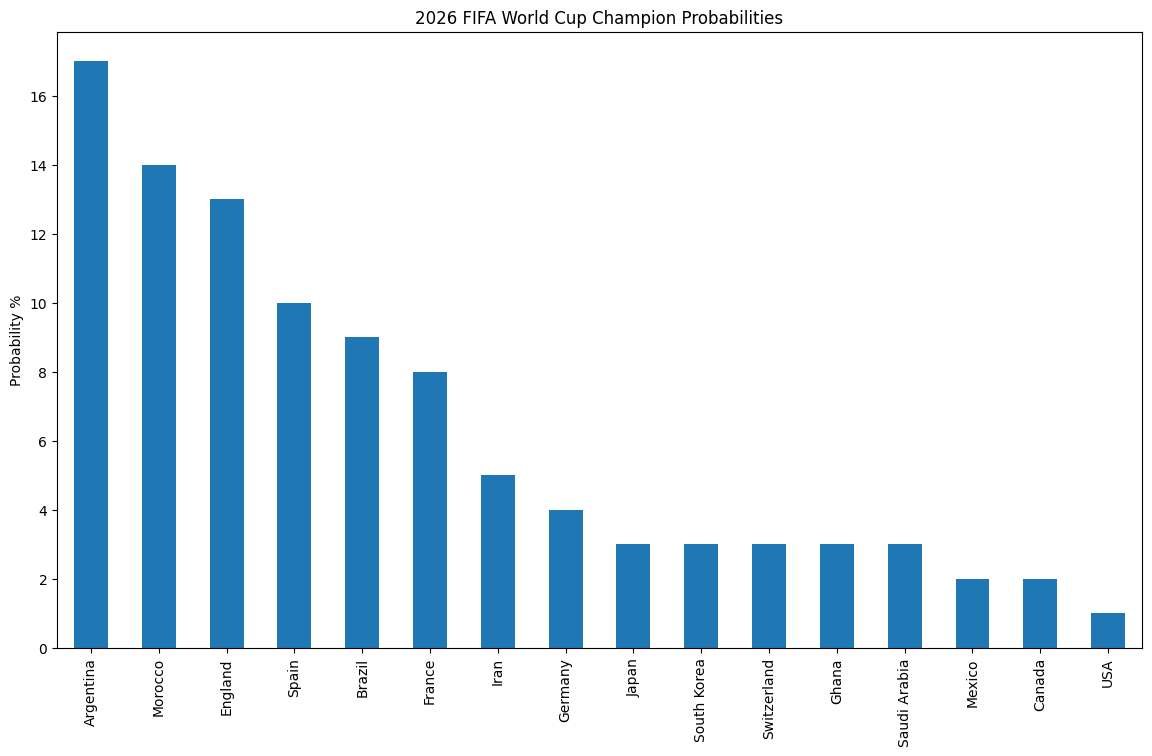

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

champion_probs.plot(
    kind='bar'
)

plt.title(
    "2026 FIFA World Cup Champion Probabilities"
)

plt.ylabel("Probability %")

plt.show()